In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics & split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# ======================
# Load dataset
# ======================
df = pd.read_csv("required csv/diabetes_binary_health_indicators_BRFSS2015.csv")

# Features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [3]:
# ======================
# Models to train
# ======================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # "SVM (RBF Kernel)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

train_accuracies = {}
test_accuracies = {}
train_times = {}

In [4]:
# ======================
# Training loop
# ======================
for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Store results
    train_accuracies[name] = train_acc
    test_accuracies[name] = test_acc
    train_times[name] = end_time - start_time

    print(f"{name} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, Time: {train_times[name]:.2f}s")


Training Logistic Regression...
Logistic Regression - Train Acc: 0.8479, Test Acc: 0.8481, Time: 6.45s

Training Random Forest...
Random Forest - Train Acc: 0.9932, Test Acc: 0.8451, Time: 38.36s

Training XGBoost...


c:\Users\vimal\anaconda3\envs\gpu_lab\lib\site-packages\xgboost\training.py:199: UserWarning: [15:11:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Train Acc: 0.8615, Test Acc: 0.8505, Time: 0.68s

Training LightGBM...
[LightGBM] [Info] Number of positive: 31982, number of negative: 170962
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009225 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 201
[LightGBM] [Info] Number of data points in the train set: 202944, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.157590 -> initscore=-1.676268
[LightGBM] [Info] Start training from score -1.676268
LightGBM - Train Acc: 0.8547, Test Acc: 0.8523, Time: 3.65s


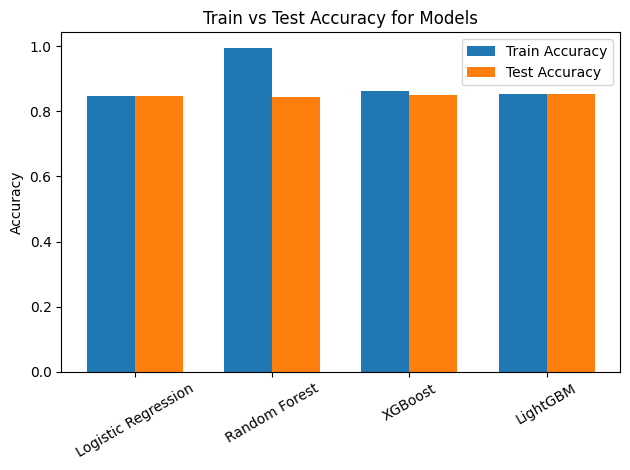

In [5]:
# ======================
# Plot Accuracy Graph
# ======================
model_names = list(models.keys())

x = np.arange(len(model_names))
width = 0.35

plt.figure()
plt.bar(x - width/2, [train_accuracies[m] for m in model_names], width, label="Train Accuracy")
plt.bar(x + width/2, [test_accuracies[m] for m in model_names], width, label="Test Accuracy")

plt.xticks(x, model_names, rotation=30)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy for Models")
plt.legend()
plt.tight_layout()
plt.show()


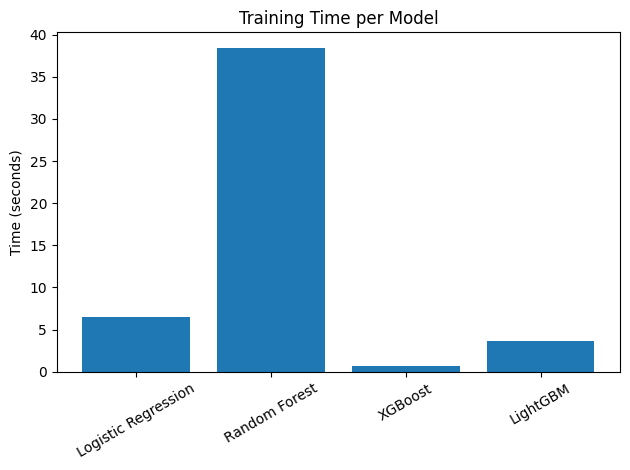

In [6]:
# ======================
# Optional: Training Time Plot
# ======================
plt.figure()
plt.bar(model_names, [train_times[m] for m in model_names])
plt.xticks(rotation=30)
plt.ylabel("Time (seconds)")
plt.title("Training Time per Model")
plt.tight_layout()
plt.show()


---